In [1]:
import os
import matplotlib.pyplot as plt
import cv2

# Path to dataset
dataset_path = "../dataset/PlantVillage"

# Get all classes
classes = os.listdir(dataset_path)
print(f"Total Classes: {len(classes)}")
print("\nAll Classes:")
for i, cls in enumerate(classes):
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"{i+1}. {cls} → {count} images")

Total Classes: 16

All Classes:
1. Pepper__bell___Bacterial_spot → 997 images
2. Pepper__bell___healthy → 1478 images
3. PlantVillage → 15 images
4. Potato___Early_blight → 1000 images
5. Potato___healthy → 152 images
6. Potato___Late_blight → 1000 images
7. Tomato_Bacterial_spot → 2127 images
8. Tomato_Early_blight → 1000 images
9. Tomato_healthy → 1591 images
10. Tomato_Late_blight → 1909 images
11. Tomato_Leaf_Mold → 952 images
12. Tomato_Septoria_leaf_spot → 1771 images
13. Tomato_Spider_mites_Two_spotted_spider_mite → 1676 images
14. Tomato__Target_Spot → 1404 images
15. Tomato__Tomato_mosaic_virus → 373 images
16. Tomato__Tomato_YellowLeaf__Curl_Virus → 3209 images


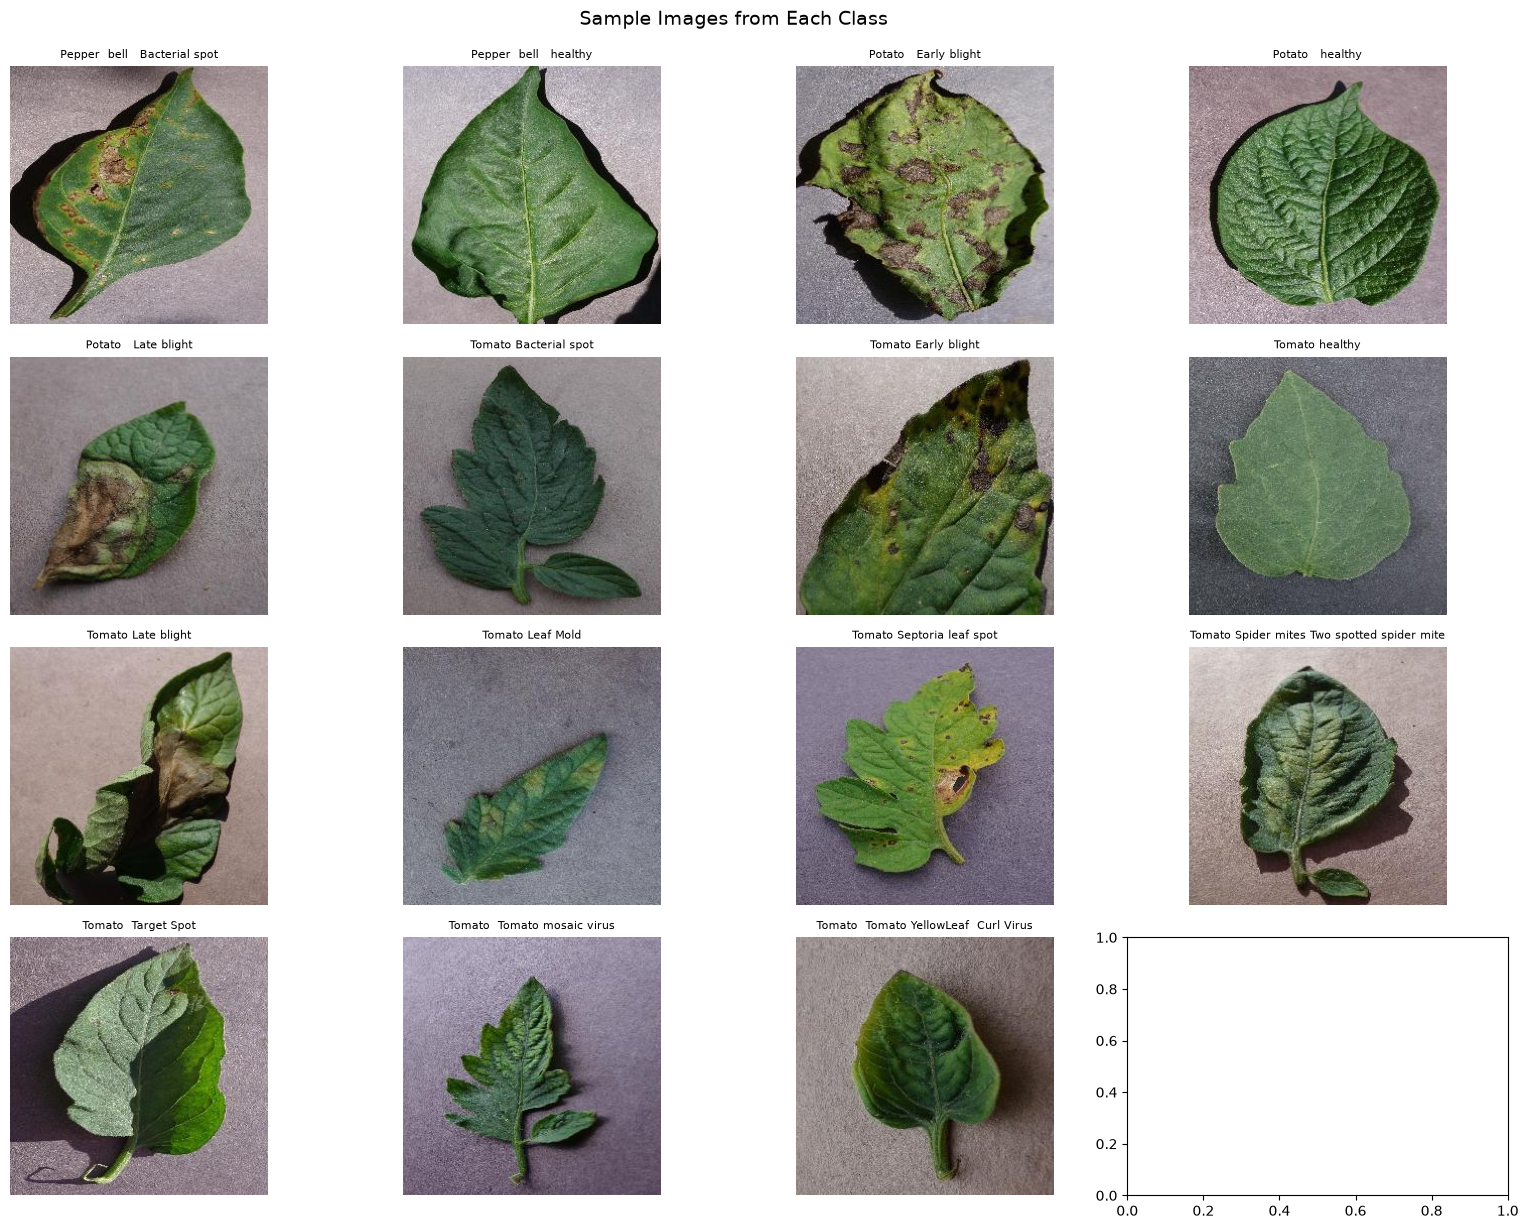


Total valid classes: 15


In [2]:
# Show sample images from each class
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

# Skip the nested PlantVillage folder
valid_classes = [cls for cls in classes if cls != "PlantVillage"]

for i, cls in enumerate(valid_classes):
    class_path = os.path.join(dataset_path, cls)
    img_file = os.listdir(class_path)[0]  # Get first image
    img_path = os.path.join(class_path, img_file)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(img)
    axes[i].set_title(cls.replace("_", " "), fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.suptitle("Sample Images from Each Class", fontsize=14, y=1.02)
plt.show()

print(f"\nTotal valid classes: {len(valid_classes)}")

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Settings
dataset_path = "../dataset/PlantVillage"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Remove the nested PlantVillage folder from training
import shutil
import os

nested = os.path.join(dataset_path, "PlantVillage")
if os.path.exists(nested):
    shutil.rmtree(nested)
    print("Removed nested PlantVillage folder ✅")

# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize 0-1
    rotation_range=20,        # Rotate images
    zoom_range=0.2,           # Zoom
    horizontal_flip=True,     # Flip
    brightness_range=[0.8, 1.2],  # Brightness
    validation_split=0.2      # 80% train, 20% validation
)

# Training Data
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

# Validation Data
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print(f"\nTotal Training Images: {train_data.samples}")
print(f"Total Validation Images: {val_data.samples}")
print(f"Total Classes: {train_data.num_classes}")
print(f"\nClass Labels:")
for cls, idx in train_data.class_indices.items():
    print(f"  {idx}: {cls}")


Removed nested PlantVillage folder ✅
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.

Total Training Images: 16516
Total Validation Images: 4122
Total Classes: 15

Class Labels:
  0: Pepper__bell___Bacterial_spot
  1: Pepper__bell___healthy
  2: Potato___Early_blight
  3: Potato___Late_blight
  4: Potato___healthy
  5: Tomato_Bacterial_spot
  6: Tomato_Early_blight
  7: Tomato_Late_blight
  8: Tomato_Leaf_Mold
  9: Tomato_Septoria_leaf_spot
  10: Tomato_Spider_mites_Two_spotted_spider_mite
  11: Tomato__Target_Spot
  12: Tomato__Tomato_YellowLeaf__Curl_Virus
  13: Tomato__Tomato_mosaic_virus
  14: Tomato_healthy


In [4]:
import json

# Save class labels to a file
class_indices = train_data.class_indices

# Reverse it: {0: "Tomato_Healthy", 1: "Tomato_Early_blight", ...}
class_labels = {v: k for k, v in class_indices.items()}

# Save to JSON file
with open("../model/class_labels.json", "w") as f:
    json.dump(class_labels, f, indent=4)

print("Class labels saved to model/class_labels.json ✅")
print("\nYour class labels:")
for idx, name in class_labels.items():
    print(f"  {idx}: {name}")

Class labels saved to model/class_labels.json ✅

Your class labels:
  0: Pepper__bell___Bacterial_spot
  1: Pepper__bell___healthy
  2: Potato___Early_blight
  3: Potato___Late_blight
  4: Potato___healthy
  5: Tomato_Bacterial_spot
  6: Tomato_Early_blight
  7: Tomato_Late_blight
  8: Tomato_Leaf_Mold
  9: Tomato_Septoria_leaf_spot
  10: Tomato_Spider_mites_Two_spotted_spider_mite
  11: Tomato__Target_Spot
  12: Tomato__Tomato_YellowLeaf__Curl_Virus
  13: Tomato__Tomato_mosaic_virus
  14: Tomato_healthy
